# Tidal Stream Simulation

Simulation of a disrupting satellite galaxy (globular cluster–like) orbiting inside a host galaxy, exposed to tidal stripping and dynamical friction.

**Two methods run in parallel:**
- **Restricted N-body** — satellite particles feel the host + moving satellite potential, but do not self-interact. Fast.
- **Full N-body** — particles self-interact via `pyfalcon` (falcON fast-multipole method) plus an external host potential and Chandrasekhar dynamical friction.

Based on: [GalacticDynamics-Oxford/Agama example_tidal_stream.py](https://github.com/GalacticDynamics-Oxford/Agama/blob/master/py/example_tidal_stream.py)

---

## Background

### The N-Body Problem

The N-body problem describes the gravitational motion of $N$ point masses. For $N>2$ there is no general closed-form solution — we integrate numerically. The equations of motion for particle $i$ are:

$$\ddot{\mathbf{r}}_i = -\sum_{j \neq i} \frac{G m_j (\mathbf{r}_i - \mathbf{r}_j)}{|\mathbf{r}_i -\mathbf{r}_j|^3 + \epsilon^3}$$

where $\epsilon$ is a **softening length** that prevents the force from diverging at close encounters. Direct summation scales as $O(N^2)$; tree codes like **falcON** (used here via `pyfalcon`) achieve $O(N \log N)$ by grouping distant particles into multipole approximations.

### Globular Clusters

Globular clusters (GCs) are dense, gravitationally bound collections of $10^4$–$10^6$ stars that orbit a host galaxy as satellites. Key properties:
- Old stellar populations ($> 10$ Gyr)
- Spherically symmetric, described by King or Dehnen density profiles
- Subject to **tidal stripping** — the host's tidal field strips stars from the leading and trailing Lagrange points
- Subject to **dynamical friction** — gravitational drag from the host's mass distribution that saps orbital energy and drives the orbit inward

### Tidal Streams

Stripped stars form two tidal tails: one ahead of the cluster (leading arm) and one behind (trailing arm). Because stripped stars conserve nearly the same orbital energy as the cluster, the tails trace out a thin ribbon that closely follows the cluster's past orbit — making streams a powerful probe of the Galactic potential.

### Chandrasekhar Dynamical Friction

The drag force on a massive body of mass $M$ moving at velocity $v$ through a background of stars with local density $\rho$ and velocity dispersion $\sigma$ is:

$$\mathbf{a}_{\rm DF} = -\frac{4\pi G^2 M \rho \ln\Lambda}{v^3} \left[{\rm erf}(X) - \frac{2X}{\sqrt{\pi}} e^{-X^2}\right] \mathbf{v}$$

where $X = v / (\sqrt{2}\,\sigma)$ and $\ln\Lambda$ is the Coulomb logarithm ($\approx 3$ here).

---

## 1. Imports and Units

In [1]:
%matplotlib widget
import numpy
import scipy.special
import scipy.integrate
import matplotlib.pyplot as plt
import agama

try:
    import pyfalcon
    print(f'pyfalcon available')
except ImportError:
    pyfalcon = None
    print('pyfalcon not available — full N-body simulation will be skipped')

agama.setUnits(length=1, velocity=1, mass=1)
print(f'G = {agama.G:.6g}  |  agama {agama.__version__}')

pyfalcon available
G = 4.30092e-06  |  agama 1.0.159 compiled on Jun 19 2026


## 2. Host Galaxy Potential (NFW Halo)

We use a spherical NFW (Navarro–Frenk–White) profile:
$$\rho(r) = \frac{\rho_0}{(r/r_s)(1 + r/r_s)^2}$$
This is a special case of the Dehnen/Hernquist family with inner slope $\gamma=1$, outer slope $\beta=3$.

We normalise so that the circular velocity at $r = 10\,\text{kpc}$ equals $200\,\text{km/s}$.

Vcirc(10 kpc) = 200.0 km/s  (target: 200 km/s)


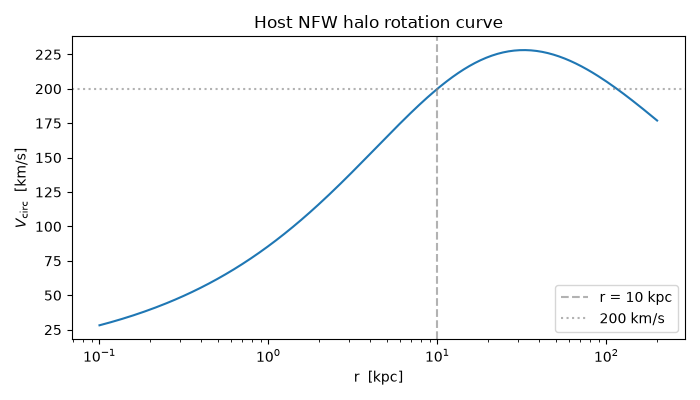

In [2]:
pot_host_params = dict(type='spheroid', gamma=1, beta=3, scaleradius=15.0, densitynorm=1)
vcirc1 = (-agama.Potential(pot_host_params).force(10, 0, 0)[0] * 10) ** 0.5
pot_host_params['densitynorm'] = (200.0 / vcirc1) ** 2
pot_host = agama.Potential(pot_host_params)

# Verify normalisation
vcirc_check = (-10 * pot_host.force(10, 0, 0)[0]) ** 0.5
print(f'Vcirc(10 kpc) = {vcirc_check:.1f} km/s  (target: 200 km/s)')

# Plot the rotation curve
r_arr = numpy.logspace(-1, 2.3, 200)
vcirc_arr = (-r_arr * pot_host.force(numpy.column_stack([r_arr, numpy.zeros_like(r_arr), numpy.zeros_like(r_arr)]))[:, 0]) ** 0.5

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(r_arr, vcirc_arr)
ax.axvline(10, color='gray', linestyle='--', alpha=0.6, label='r = 10 kpc')
ax.axhline(200, color='gray', linestyle=':', alpha=0.6, label='200 km/s')
ax.set_xscale('log')
ax.set_xlabel('r  [kpc]')
ax.set_ylabel('$V_{\\rm circ}$  [km/s]')
ax.set_title('Host NFW halo rotation curve')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Host Velocity Dispersion Profile

Needed for the Chandrasekhar dynamical friction formula. We compute $\sigma(r)$ from the quasi-spherical distribution function of the host and interpolate with a log-spline.

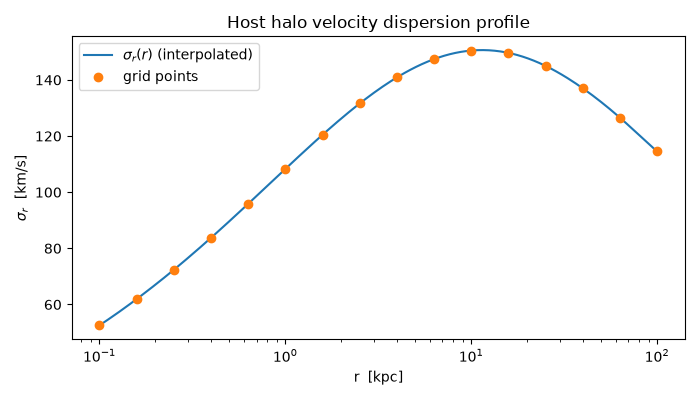

In [3]:
df_host  = agama.DistributionFunction(type='quasispherical', potential=pot_host)
grid_r   = numpy.logspace(-1, 2, 16)
grid_sig = agama.GalaxyModel(pot_host, df_host).moments(
    numpy.column_stack((grid_r, grid_r * 0, grid_r * 0)),
    dens=False, vel=False, vel2=True
)[:, 0] ** 0.5

logspl = agama.Spline(numpy.log(grid_r), numpy.log(grid_sig))
sigma  = lambda r: numpy.exp(logspl(numpy.log(r)))

r_plot = numpy.logspace(-1, 2, 200)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(r_plot, sigma(r_plot), label='$\\sigma_r(r)$ (interpolated)')
ax.scatter(grid_r, grid_sig, color='C1', zorder=5, label='grid points')
ax.set_xscale('log')
ax.set_xlabel('r  [kpc]')
ax.set_ylabel('$\\sigma_r$  [km/s]')
ax.set_title('Host halo velocity dispersion profile')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Satellite Galaxy (Globular Cluster)

The satellite is a Dehnen sphere with inner slope $\gamma=1$, outer slope $\beta=4$, and a Gaussian truncation at $r_{\rm cut} = 8\,\text{kpc}$. Initial mass $\sim 10^9\,M_\odot$.

We sample $N_{\rm body}$ particles from its isotropic DF.

Satellite total mass: 1e+09 Msun
Sampled 10000 particles, total sampled mass = 9.998e+08 Msun


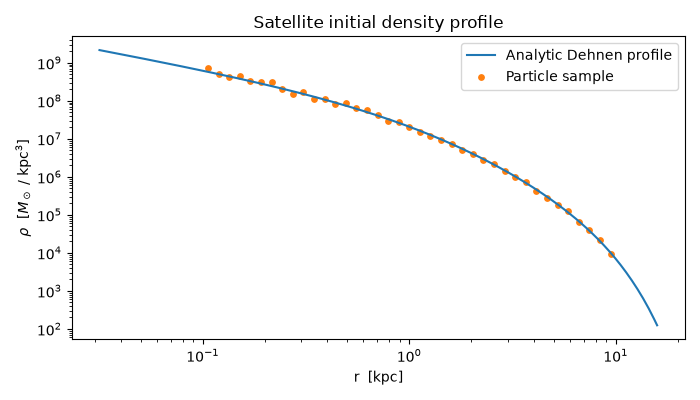

In [4]:
pot_sat  = agama.Potential(type='spheroid', gamma=1, beta=4,
                           scaleradius=2.0, outercutoffradius=8.0, mass=1e9)
initmass = pot_sat.totalMass()
print(f'Satellite total mass: {initmass:.4g} Msun')

df_sat     = agama.DistributionFunction(type='quasispherical', potential=pot_sat)
Nbody      = 10000
xv, mass   = agama.GalaxyModel(pot_sat, df_sat).sample(Nbody)
print(f'Sampled {Nbody} particles, total sampled mass = {mass.sum():.4g} Msun')

# Plot initial density profile
r_particles = numpy.sum(xv[:, 0:3] ** 2, axis=1) ** 0.5
r_bins = numpy.logspace(-1, 1, 40)
counts, _ = numpy.histogram(r_particles, bins=r_bins)
vol = (4/3) * numpy.pi * (r_bins[1:] ** 3 - r_bins[:-1] ** 3)
r_mid = (r_bins[:-1] * r_bins[1:]) ** 0.5
rho_particles = counts * (mass[0] / vol)

r_theory = numpy.logspace(-1.5, 1.2, 200)
rho_theory = pot_sat.density(numpy.column_stack([r_theory, r_theory * 0, r_theory * 0]))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(r_theory, rho_theory, label='Analytic Dehnen profile')
ax.scatter(r_mid, rho_particles, s=15, color='C1', label='Particle sample')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('r  [kpc]')
ax.set_ylabel('$\\rho$  [$M_\\odot$ / kpc$^3$]')
ax.set_title('Satellite initial density profile')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Initial Conditions

Place the satellite at the apocentre of a moderately eccentric orbit at $R_0 = 50\,\text{kpc}$, with tangential speed $V_0 = 0.7\,V_{\rm circ}(R_0)$.

In [5]:
R0    = 50.0
Vcirc = (-R0 * pot_host.force(R0, 0, 0)[0]) ** 0.5
V0    = 0.7 * Vcirc
print(f'Orbit: R0 = {R0} kpc,  Vcirc(R0) = {Vcirc:.1f} km/s,  V0 = {V0:.1f} km/s')
print(f'Orbital eccentricity (approx): V0/Vcirc = {V0/Vcirc:.2f}')

r_center = numpy.array([R0, 0, 0, 0, V0, 0])  # [x, y, z, vx, vy, vz]
xv      += r_center  # shift all particles to satellite frame

Orbit: R0 = 50.0 kpc,  Vcirc(R0) = 224.3 km/s,  V0 = 157.0 km/s
Orbital eccentricity (approx): V0/Vcirc = 0.70


## 6. Simulation Parameters

In [6]:
tend = 3.0    # total simulation time [Gyr equivalent in these units]
tupd = 2**-2  # update interval (restricted N-body particle advancement + plot)
tau  = 2**-8  # leapfrog timestep for full N-body (tau << eps/v_internal)
eps  = 0.1    # gravitational softening length [kpc]

print(f'tend = {tend},  tupd = {tupd:.4f},  tau = {tau:.6f},  eps = {eps}')
print(f'Steps per update interval: {int(tupd/tau)}')
print(f'Total update intervals: {int(tend/tupd)}')

tend = 3.0,  tupd = 0.2500,  tau = 0.003906,  eps = 0.1
Steps per update interval: 64
Total update intervals: 12


## 7. Physics Functions

### Chandrasekhar Dynamical Friction

The friction deceleration on the satellite centre moving at velocity $\mathbf{v}$ is:
$$\mathbf{a}_{\rm DF} = -\frac{4\pi G^2 M \rho \ln\Lambda}{v^3}
\left[{\rm erf}(X) - \frac{2X}{\sqrt{\pi}}e^{-X^2}\right] \hat{\mathbf{v}},
\quad X = \frac{v}{\sqrt{2}\,\sigma(r)}$$

In [7]:
def dynfricAccel(pos, vel, sat_mass):
    r          = sum(pos ** 2) ** 0.5
    v          = sum(vel ** 2) ** 0.5
    rho        = pot_host.density(pos)
    coulombLog = 3.0
    X          = v / (2 ** 0.5 * sigma(r))
    factor     = (scipy.special.erf(X) - 2 / numpy.pi ** 0.5 * X * numpy.exp(-X * X))
    return -vel / v * (4 * numpy.pi * agama.G ** 2 * sat_mass * rho * coulombLog * factor / v ** 2)


def orbitDF(ic, time, timestart, trajsize, sat_mass):
    """Integrate the satellite centre-of-mass orbit, optionally including DF."""
    if sat_mass == 0:
        return agama.orbit(ic=ic, potential=pot_host,
                           time=time, timestart=timestart, trajsize=trajsize)
    times = numpy.linspace(timestart, timestart + time, trajsize)
    traj  = scipy.integrate.odeint(
        lambda xv, t: numpy.hstack((
            xv[3:6],
            pot_host.force(xv[0:3], t=t) + dynfricAccel(xv[0:3], xv[3:6], sat_mass)
        )),
        ic, times
    )
    return times, traj

## 8. Initialise State

Set up the initial arrays for both simulation methods.

In [8]:
# Reset all simulation state (re-run this cell to restart the simulation)
pot_sat  = agama.Potential(type='spheroid', gamma=1, beta=4,
                           scaleradius=2.0, outercutoffradius=8.0, mass=1e9)

r_center = numpy.array([R0, 0, 0, 0, V0, 0])

S = dict(
    time     = 0.0,
    r_center = r_center.copy(),
    r_xv     = xv.copy(),
    pot_sat  = pot_sat,
    r_mass   = [initmass],
    r_bound  = numpy.ones(Nbody, bool),
    r_traj   = [r_center.copy()],
    times_t  = [0.0],
    times_u  = [0.0],
    f_center = r_center.copy(),
    f_xv     = xv.copy(),
    f_mass   = [initmass],
    f_traj   = [r_center.copy()],
    f_times  = [0.0],
    f_bound  = numpy.ones(Nbody, bool),
    f_acc    = None,
    f_pot    = None,
)
print('State initialised. Ready to animate.')

State initialised. Ready to animate.


## 9. Live Simulation

The figure below updates in real time as the simulation runs. Blue dots are **bound** particles; red dots have been **stripped** into the tidal stream. The green line traces the satellite centre-of-mass orbit. Top panels show galactocentric distance (red) and bound mass fraction (blue) vs time.

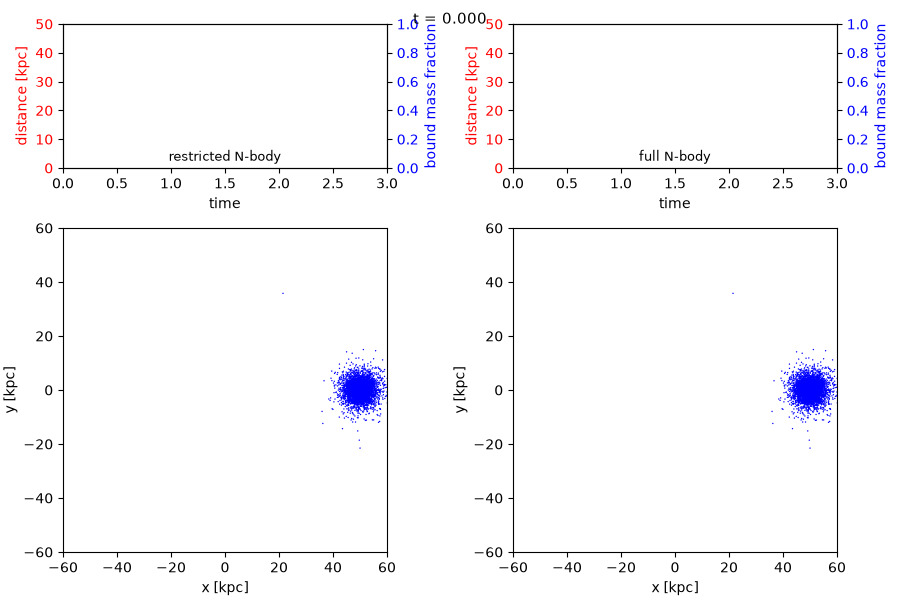

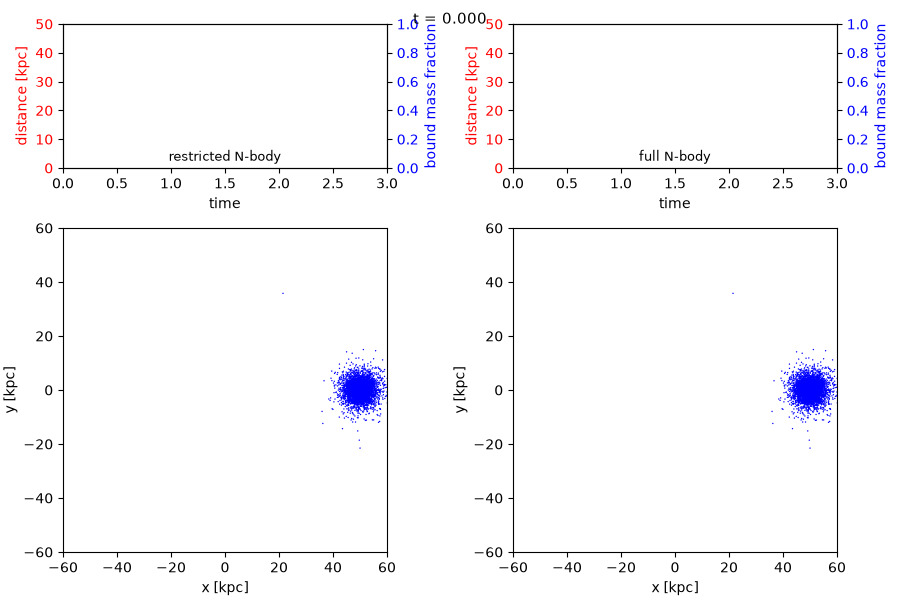

In [9]:
from matplotlib.animation import FuncAnimation

# ── Figure layout (mirrors original example_tidal_stream.py) ─────────────────
fig = plt.figure(figsize=(9, 6), dpi=100)
ax1 = fig.add_axes([0.07, 0.08, 0.36, 0.54])
ax2 = fig.add_axes([0.57, 0.08, 0.36, 0.54])
bx1 = fig.add_axes([0.07, 0.72, 0.36, 0.24])
bx2 = fig.add_axes([0.57, 0.72, 0.36, 0.24])
cx1 = bx1.twinx()
cx2 = bx2.twinx()

for ax in (ax1, ax2):
    ax.set_xlim(-60, 60); ax.set_ylim(-60, 60)
    ax.set_xlabel('x [kpc]'); ax.set_ylabel('y [kpc]')
for bx in (bx1, bx2):
    bx.set_xlim(0, tend); bx.set_ylim(0, R0)
    bx.set_xlabel('time'); bx.set_ylabel('distance [kpc]', color='r')
    bx.tick_params(axis='y', labelcolor='r')
for cx in (cx1, cx2):
    cx.set_ylim(0, 1)
    cx.set_ylabel('bound mass fraction', color='b')
    cx.tick_params(axis='y', labelcolor='b')

bx1.text(0.5, 0.05, 'restricted N-body', ha='center', transform=bx1.transAxes, fontsize=9)
bx2.text(0.5, 0.05, 'full N-body' if pyfalcon else 'full N-body (n/a)',
         ha='center', transform=bx2.transAxes, fontsize=9)

# Initial artists
sc1 = ax1.scatter(S['r_xv'][:, 0], S['r_xv'][:, 1], marker='o', s=1,
                  linewidths=0, c=numpy.ones(Nbody), cmap='bwr_r', vmin=0, vmax=1)
traj1,      = ax1.plot([], [], 'g', lw=0.7, alpha=0.8)
dist_line1, = bx1.plot([], [], 'r', lw=0.9)
mass_line1, = cx1.plot([], [], 'b', lw=0.9)

if pyfalcon:
    sc2 = ax2.scatter(S['f_xv'][:, 0], S['f_xv'][:, 1], marker='o', s=1,
                      linewidths=0, c=numpy.ones(Nbody), cmap='bwr_r', vmin=0, vmax=1)
    traj2,      = ax2.plot([], [], 'g', lw=0.7, alpha=0.8)
    dist_line2, = bx2.plot([], [], 'r', lw=0.9)
    mass_line2, = cx2.plot([], [], 'b', lw=0.9)
else:
    ax2.text(0.5, 0.5, 'pyfalcon not available', ha='center', va='center',
             transform=ax2.transAxes, color='gray', fontsize=11)

title = fig.suptitle('t = 0.000', fontsize=11)
plt.show()

# ── FuncAnimation frame function ──────────────────────────────────────────────
def step(frame):
    s = S
    if s['time'] >= tend:
        ani.event_source.stop()
        return

    # Method 1: Restricted N-body
    time_center, orbit_center = orbitDF(
        ic=s['r_center'], time=tupd, timestart=s['time'],
        trajsize=round(tupd / tau) + 1, sat_mass=s['r_mass'][-1]
    )
    s['times_u'].append(time_center[-1])
    s['times_t'].extend(time_center[1:])
    s['r_traj'].extend(orbit_center[1:])
    s['r_center'] = orbit_center[-1]

    pot_total = agama.Potential(
        pot_host,
        agama.Potential(potential=s['pot_sat'],
                        center=numpy.column_stack((time_center, orbit_center)))
    )
    s['r_xv'] = agama.orbit(
        ic=s['r_xv'], potential=pot_total, time=tupd, timestart=s['time'],
        trajsize=1, separateTime=True
    )[1].reshape(Nbody, 6)

    s['pot_sat'] = agama.Potential(
        type='multipole',
        particles=(s['r_xv'][:, 0:3] - s['r_center'][0:3], mass),
        symmetry='s'
    )
    s['r_bound'] = (
        s['pot_sat'].potential(s['r_xv'][:, 0:3] - s['r_center'][0:3])
        + 0.5 * numpy.sum((s['r_xv'][:, 3:6] - s['r_center'][3:6]) ** 2, axis=1)
    ) < 0
    s['r_mass'].append(numpy.sum(mass[s['r_bound']]))

    # Method 2: Full N-body with pyfalcon
    if pyfalcon:
        if s['f_acc'] is None:
            s['f_acc'], s['f_pot'] = pyfalcon.gravity(s['f_xv'][:, 0:3], agama.G * mass, eps)
            s['f_acc'] += pot_host.force(s['f_xv'][:, 0:3]) + \
                          dynfricAccel(s['f_center'][0:3], s['f_center'][3:6], initmass)

        f_time = 0
        while f_time < tupd:
            s['f_xv'][:, 3:6] += s['f_acc'] * (tau / 2)
            s['f_xv'][:, 0:3] += s['f_xv'][:, 3:6] * tau
            s['f_acc'], s['f_pot'] = pyfalcon.gravity(s['f_xv'][:, 0:3], agama.G * mass, eps)
            s['f_acc'] += pot_host.force(s['f_xv'][:, 0:3])
            s['f_acc'] += dynfricAccel(s['f_center'][0:3], s['f_center'][3:6],
                                       numpy.sum(mass[s['f_bound']]))
            s['f_xv'][:, 3:6] += s['f_acc'] * (tau / 2)

            s['f_center'][0:3] += tau * s['f_center'][3:6]
            Rmax = 10.0
            use = numpy.sum((s['f_xv'][:, 0:3] - s['f_center'][0:3]) ** 2, axis=1) < Rmax ** 2
            prev = s['f_center'].copy()
            for _ in range(10):
                s['f_center'] = numpy.median(s['f_xv'][use], axis=0)
                s['f_bound'] = s['f_pot'] + 0.5 * numpy.sum(
                    (s['f_xv'][:, 3:6] - s['f_center'][3:6]) ** 2, axis=1) < 0
                if numpy.sum(s['f_bound']) <= 1 or all(s['f_center'] == prev):
                    break
                use = s['f_bound'] & (numpy.sum(
                    (s['f_xv'][:, 0:3] - s['f_center'][0:3]) ** 2, axis=1) < Rmax ** 2)
                prev = s['f_center'].copy()
            s['f_traj'].append(s['f_center'].copy())
            s['f_times'].append(s['time'] + f_time + tau)
            s['f_mass'].append(numpy.sum(mass[s['f_bound']]))
            f_time += tau

    s['time'] += tupd

    # Update artists in-place
    r_traj_arr = numpy.vstack(s['r_traj'])
    sc1.set_offsets(s['r_xv'][:, 0:2])
    sc1.set_array(s['r_bound'].astype(float))
    traj1.set_data(r_traj_arr[:, 0], r_traj_arr[:, 1])
    dist_line1.set_data(s['times_t'][:len(r_traj_arr)],
                        numpy.sum(r_traj_arr[:, 0:3] ** 2, axis=1) ** 0.5)
    mass_line1.set_data(s['times_u'], numpy.array(s['r_mass']) / initmass)

    if pyfalcon:
        f_traj_arr = numpy.vstack(s['f_traj'])
        sc2.set_offsets(s['f_xv'][:, 0:2])
        sc2.set_array(s['f_bound'].astype(float))
        traj2.set_data(f_traj_arr[:, 0], f_traj_arr[:, 1])
        dist_line2.set_data(s['f_times'], numpy.sum(f_traj_arr[:, 0:3] ** 2, axis=1) ** 0.5)
        mass_line2.set_data(s['f_times'], numpy.array(s['f_mass']) / initmass)

    title.set_text(
        f't = {s["time"]:.3f}  |  bound: {s["r_mass"][-1]/initmass:.1%}'
        + (f'  (Nbody: {s["f_mass"][-1]/initmass:.1%})' if pyfalcon else '')
    )

# frames=None runs until ani.event_source.stop() is called inside step()
ani = FuncAnimation(fig, step, frames=int(tend / tupd),
                    interval=50, blit=False, repeat=False)
plt.show()

In [11]:
# Extract results from animation state dictionary
r_traj = S['r_traj']
r_xv = S['r_xv']
r_bound = S['r_bound']
r_mass = S['r_mass']
times_t = S['times_t']
times_u = S['times_u']

if pyfalcon:
    f_traj = S['f_traj']
    f_xv = S['f_xv']
    f_bound = S['f_bound']
    f_mass = S['f_mass']
    f_times = S['f_times']

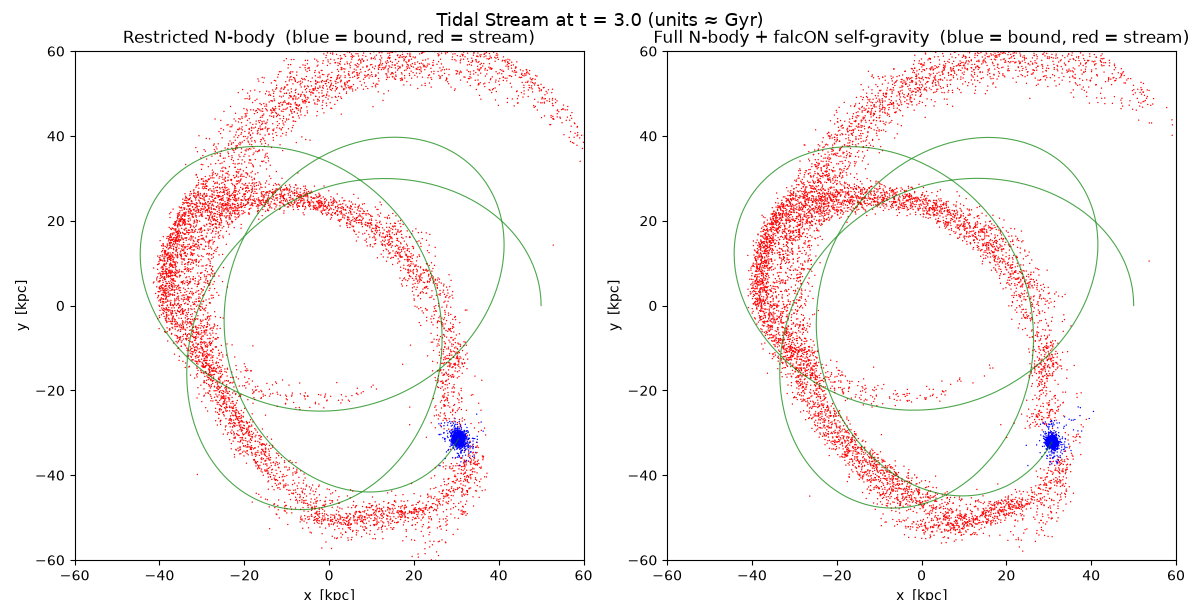

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

r_traj_arr = numpy.vstack(r_traj)

# Restricted N-body
ax = axes[0]
sc = ax.scatter(r_xv[:, 0], r_xv[:, 1], marker='o', s=1,
                linewidths=0, edgecolors='none',
                c=r_bound.astype(float), cmap='bwr_r', vmin=0, vmax=1)
ax.plot(r_traj_arr[:, 0], r_traj_arr[:, 1], 'g', lw=0.8, alpha=0.7)
ax.set_xlim(-60, 60)
ax.set_ylim(-60, 60)
ax.set_xlabel('x  [kpc]')
ax.set_ylabel('y  [kpc]')
ax.set_title('Restricted N-body  (blue = bound, red = stream)')
ax.set_aspect('equal')

# Full N-body
ax = axes[1]
if pyfalcon:
    f_traj_arr = numpy.vstack(f_traj)
    ax.scatter(f_xv[:, 0], f_xv[:, 1], marker='o', s=1,
               linewidths=0, edgecolors='none',
               c=f_bound.astype(float), cmap='bwr_r', vmin=0, vmax=1)
    ax.plot(f_traj_arr[:, 0], f_traj_arr[:, 1], 'g', lw=0.8, alpha=0.7)
    ax.set_title('Full N-body + falcON self-gravity  (blue = bound, red = stream)')
else:
    ax.text(0.5, 0.5, 'pyfalcon not available', ha='center', va='center',
            transform=ax.transAxes, fontsize=14, color='gray')
    ax.set_title('Full N-body  (unavailable)')
ax.set_xlim(-60, 60)
ax.set_ylim(-60, 60)
ax.set_xlabel('x  [kpc]')
ax.set_ylabel('y  [kpc]')
ax.set_aspect('equal')

plt.suptitle(f'Tidal Stream at t = {tend} (units ≈ Gyr)', fontsize=13)
plt.tight_layout()
plt.show()

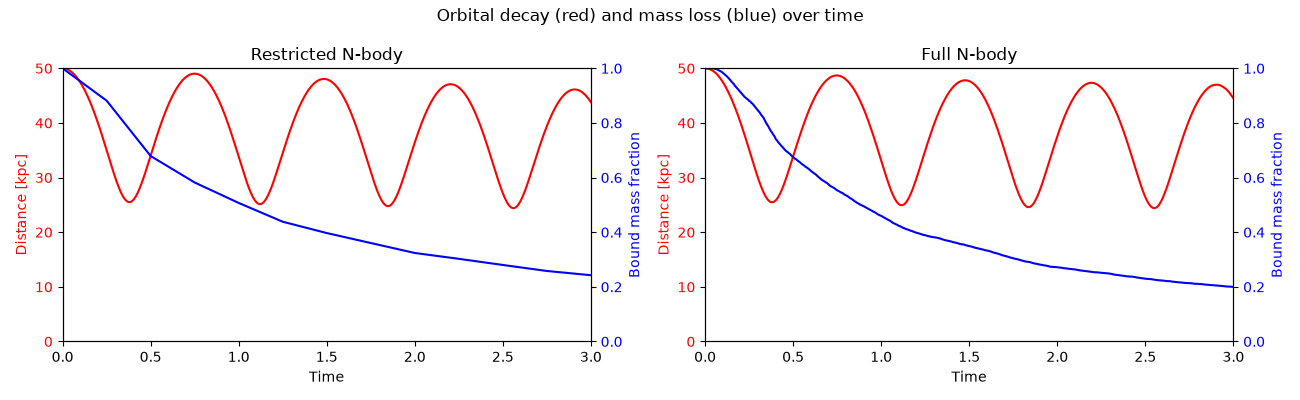

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

r_traj_arr = numpy.vstack(r_traj)
plot_cases = [(axes[0], 'Restricted N-body', r_traj_arr, times_t[:len(r_traj_arr)], r_mass, times_u)]
if pyfalcon:
    plot_cases.append((axes[1], 'Full N-body', numpy.vstack(f_traj), f_times, f_mass, f_times))
else:
    axes[1].text(0.5, 0.5, 'pyfalcon not available', ha='center', va='center', transform=axes[1].transAxes)

for ax, label, traj, times_d, masses, times_m in plot_cases:
    ax2 = ax.twinx()
    if traj is not None:
        dist = numpy.sum(traj[:, 0:3] ** 2, axis=1) ** 0.5
        ax.plot(times_d[:len(dist)], dist, 'r', label='Galactocentric distance')
    if times_m is not None:
        ax2.plot(times_m, numpy.array(masses) / initmass, 'b', label='Bound mass fraction')
    ax.set_xlim(0, tend)
    ax.set_ylim(0, R0)
    ax2.set_ylim(0, 1)
    ax.set_xlabel('Time')
    ax.set_ylabel('Distance [kpc]', color='r')
    ax2.set_ylabel('Bound mass fraction', color='b')
    ax.set_title(label)
    ax.tick_params(axis='y', labelcolor='r')
    ax2.tick_params(axis='y', labelcolor='b')

plt.suptitle('Orbital decay (red) and mass loss (blue) over time', fontsize=12)
plt.tight_layout()
plt.show()